# Recipe 01 — Hello, TensorAeroSpace

**Goal.** Get productive with the library in under 10 minutes: import, create an aerospace env, close a PID loop on an angle-of-attack command, plot the result.

**Prerequisites.** Python 3.10+, `tensoraerospace` installed (`pip install tensoraerospace` or `poetry install`).

**What you'll learn.** The three objects you'll touch in 95 % of your work:

1. A **Gymnasium env** (here `LinearLongitudinalF16-v0`) wrapping an aircraft dynamics model.
2. An **agent** (here the library's built-in `PID`).
3. A **reference signal** — the commanded trajectory the agent must track.

## 1. Imports and simulation parameters

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

import tensoraerospace  # noqa: F401 — registers all Gymnasium envs
from tensoraerospace.agent.pid import PID
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.utils import generate_time_period

dt = 0.01
tp = generate_time_period(tn=20, dt=dt)       # 20 s of sim, discretised at 100 Hz
number_time_steps = len(tp)

# A unit step of +5° in angle of attack, firing at t = 2 s.
reference_signal = np.reshape(
    unit_step(tp=tp, degree=5, time_step=2.0, output_rad=True),
    (1, -1),
)

## 2. Build the env

Every env exposes a handful of levers that decide *what* you're controlling:

| Argument | Meaning |
|---|---|
| `state_space` | Which states are observable to the agent. |
| `output_space` | Which states get exposed in `env.model_output` (for logging). |
| `tracking_states` | Which states the `reference_signal` corresponds to. |
| `reference_signal` | Desired trajectory, shape `(len(tracking_states), number_time_steps)`. |
| `use_reward` | Whether the env computes a scalar reward (not needed for PID). |

In [2]:
env = gym.make(
    'LinearLongitudinalF16-v0',
    number_time_steps=number_time_steps,
    use_reward=False,
    initial_state=[[0], [0], [0]],               # theta, alpha, q
    reference_signal=reference_signal,
    state_space=['theta', 'alpha', 'q'],
    output_space=['theta', 'alpha', 'q'],
    tracking_states=['alpha'],
)
env.reset()

(array([0., 0., 0.], dtype=float32), {})

## 3. Close a PID loop

The library's `PID` implements the MATLAB/Simulink form with anti-windup and derivative-on-measurement. It's a handy *baseline* against which all the fancier agents (MPC, IHDP, PPO, …) get compared.

In [3]:
pid = PID(env, kp=-14.29, ki=-8.24, kd=-1.30, dt=dt)

alpha_meas = []
u_trace = []
xt = np.zeros(3)                               # [theta, alpha, q] — same layout as state_space

for step in range(number_time_steps - 2):
    setpoint = float(reference_signal[0, step])
    ut = pid.select_action(setpoint, float(xt[1]))
    xt, reward, terminated, truncated, info = env.step(np.array([ut]))
    alpha_meas.append(float(xt[1]))
    u_trace.append(float(ut))

alpha_meas = np.asarray(alpha_meas)
u_trace = np.asarray(u_trace)
ref = reference_signal[0, : len(alpha_meas)]

rmse_deg = np.degrees(np.sqrt(np.mean((alpha_meas[-500:] - ref[-500:]) ** 2)))
print(f'Late-window RMSE on α: {rmse_deg:.3f}°')

Late-window RMSE on α: 0.141°


## 4. Plot

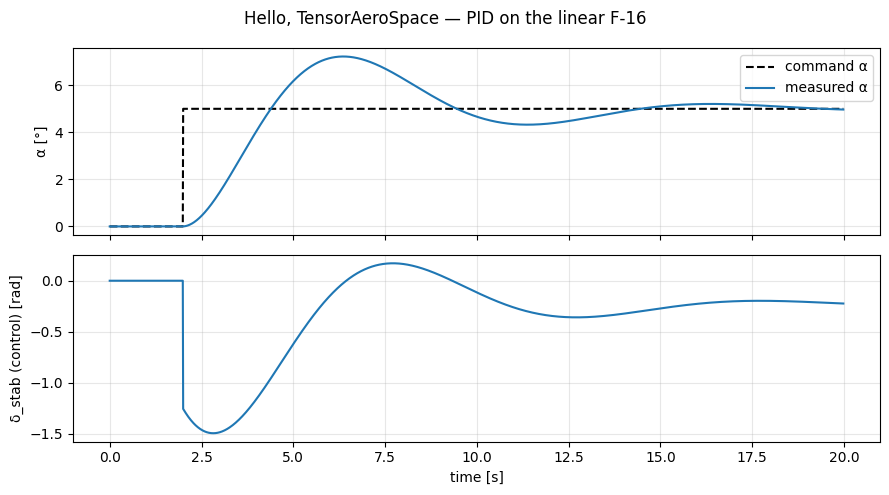

In [4]:
t = tp[: len(alpha_meas)]
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, np.degrees(ref), 'k--', label='command α')
axes[0].plot(t, np.degrees(alpha_meas), label='measured α')
axes[0].set_ylabel('α [°]')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t, u_trace)
axes[1].set_ylabel('δ_stab (control) [rad]')
axes[1].set_xlabel('time [s]')
axes[1].grid(alpha=0.3)

fig.suptitle('Hello, TensorAeroSpace — PID on the linear F-16')
plt.tight_layout()
plt.show()

## What just happened

- `gym.make('LinearLongitudinalF16-v0', ...)` returned a Gymnasium env whose **observation** is the selected state slice (`theta, alpha, q`) and whose **action** is the elevator command.
- `reference_signal` is a `(n_tracking_states, number_time_steps)` array; the env exposes it to the agent and uses it for reward computation when enabled.
- The PID didn't need any identification or training — just proportional/integral/derivative gains on the tracking error.

## Where to go next

- **[Recipe 02 — Anatomy of an env](02_env_anatomy.md)** — every env argument explained.
- **[Recipe 03 — Crafting reference signals](03_reference_signals.md)** — steps, ramps, doublets, sinusoids.
- **[Recipe 04 — Choosing an agent](04_choosing_agent.md)** — when PID is not enough.